# SC4003 Assignment 1 – Part 1
## Optimal Policy & Utilities using **Value Iteration**

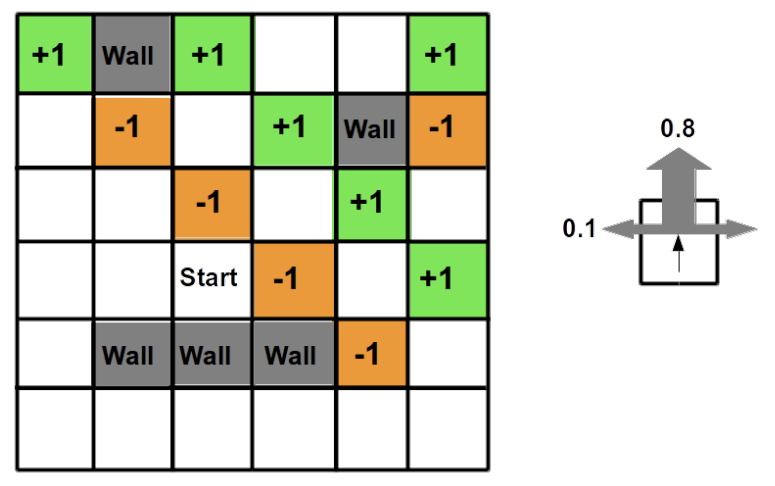

This notebook implements the gridworld:

- **Actions**: Up, Down, Left, Right  
- **Transition model**: 0.8 intended, 0.1 each perpendicular direction  
- **Wall**: Agent stays in place  
- **Rewards**: White = −0.05, Green = +1, Brown = −1  
- **No terminal states** (Infinite state sequence)  
- **Discount factor** = 0.99

---
#### Part 1
Assuming the known transition model and reward function listed above, find the optimal policy and the utilities of all the (non-wall) states using value iteration. Display the optimal policy and the utilities of all the states, and plot utility estimates as a function of the number of iterations as in Figure 17.5(a) in the above reference book. In this question, use a discount factor of 0.99. 

---
#### Deliverables for Value Iteration
1. Descriptions of implemented solutions  
2. Plot of optimal policy 
3. Utilities of all states  
4. Plot of utility estimates as a function of the number of iterations

---
#### Coordinate Convention
`(row, col)` with `(0,0)` at **top-left**.   
  
Start cell = `(3, 2)`.

## 1 Imports and Utilities

In [3]:
import os
import sys
from IPython.display import display
from common_utils import *

sys.path.append(os.getcwd())
sys.path.append('/mnt/data')

## 2 Initialisation
This initialises the Gridworld environment, defines the states that will be tracked in the convergence plots and visualises the given maze.

#### What the maze shows:
- green cells = reward `+1`
- orange/brown cells = reward `-1`
- grey cells = walls
- blue cell = start state
- white cells = normal states with reward `-0.05`

In [5]:
# Gridworld Environment Initialisation
env = Gridworld()

In [6]:
# Define States
TRACKED_STATES = DEFAULT_TRACKED_STATES

print("Start state:", env.start_state)
print("Walls:", sorted(env.walls))
print("Tracked states:", TRACKED_STATES)

Start state: (3, 2)
Walls: [(0, 1), (1, 4), (4, 1), (4, 2), (4, 3)]
Tracked states: [(0, 0), (0, 2), (0, 5), (1, 0), (2, 4), (3, 2), (3, 5), (5, 0), (5, 5)]


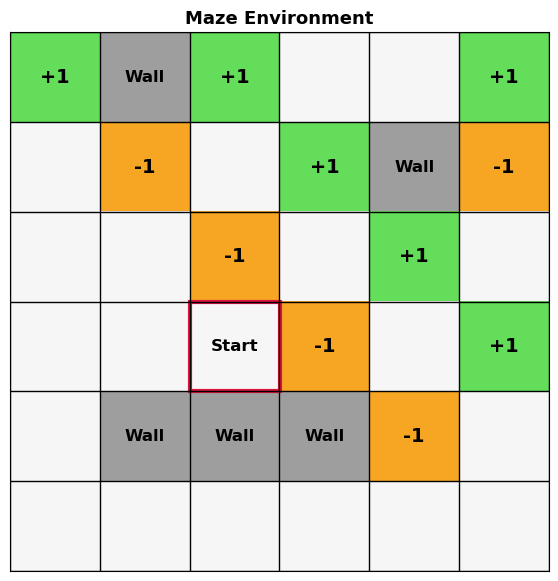

In [7]:
# Visualisation of Given Maze
plot_board(env, title='Maze Environment')

## 3 Run Value Iteration

This cell runs **Value Iteration (VI)** on the gridworld to compute the **optimal utility function** and the corresponding **optimal policy**.

---
#### What this step does
At each iteration, the algorithm performs one **full synchronous sweep** over all non-wall states:

1. Visit each non-wall state $s$.
2. For each action $a \in \{U, D, L, R\}$, compute its **expected return** under the stochastic transition model.
3. Update the utility of state $s$ to the **maximum** expected return over all actions.
4. Record the largest absolute change in utility across the sweep:

$$
\Delta = \max_s \left| U_{k+1}(s) - U_k(s) \right|
$$

This is the convergence measure used to decide when the algorithm has stabilised.

---
#### Implemented update rule
In this notebook, rewards are attached to the **next state entered**, so the update used in code is:

$$
U_{k+1}(s)
=
\max_a
\sum_{s'} P(s' \mid s,a)
\left[ R(s') + \gamma U_k(s') \right]
$$

This means the utility of a state is updated by looking one step ahead, taking the expected reward of the successor state, plus its discounted future utility.

---
#### Stopping rule
The algorithm stops when either:
- the maximum utility change falls below the tolerance `THETA`, i.e.

$$
\Delta < \theta
$$

- or the number of iterations reaches `MAX_ITERATIONS`.

Because $0 < \gamma < 1$, Value Iteration is a contraction mapping and converges to the unique optimal utility function.

---
#### Outputs returned by `value_iteration(...)`
- `U_vi`: final utility values for all non-wall states
- `policy_vi`: greedy policy derived from the converged utilities
- `vi_history`: utility snapshot after each iteration
- `vi_deltas`: maximum utility change per iteration

---
#### How to interpret the results
- **More iterations** usually indicate **slower convergence**
- **Smaller final** $\Delta$ **indicates that the utilities have numerically stabilised**

In [9]:
# Run Value Iteration
THETA = 1e-8
MAX_ITERATIONS = 10000

U_vi, policy_vi, vi_history, vi_deltas = value_iteration(
    env,
    theta=THETA,
    max_iterations=MAX_ITERATIONS,
)

print(f"Value iteration sweeps completed: {len(vi_deltas)}")
print(f"Final Bellman residual: {vi_deltas[-1]:.3e}")

Value iteration sweeps completed: 1834
Final Bellman residual: 9.984e-09


In [10]:
# Check Correctness of Result
# Every non-wall state should have a policy action because there are no terminal states.
assert set(policy_vi.keys()) == set(env.states)

# Utilities should be finite for all non-wall states.
assert all(np.isfinite(U_vi[s]) for s in env.states)

print("Checks passed.")

Checks passed.


## 4 Visualisation of Results

This section shows the **utility snapshots at different iterations** and the **optimal policy and utilities of all the states**

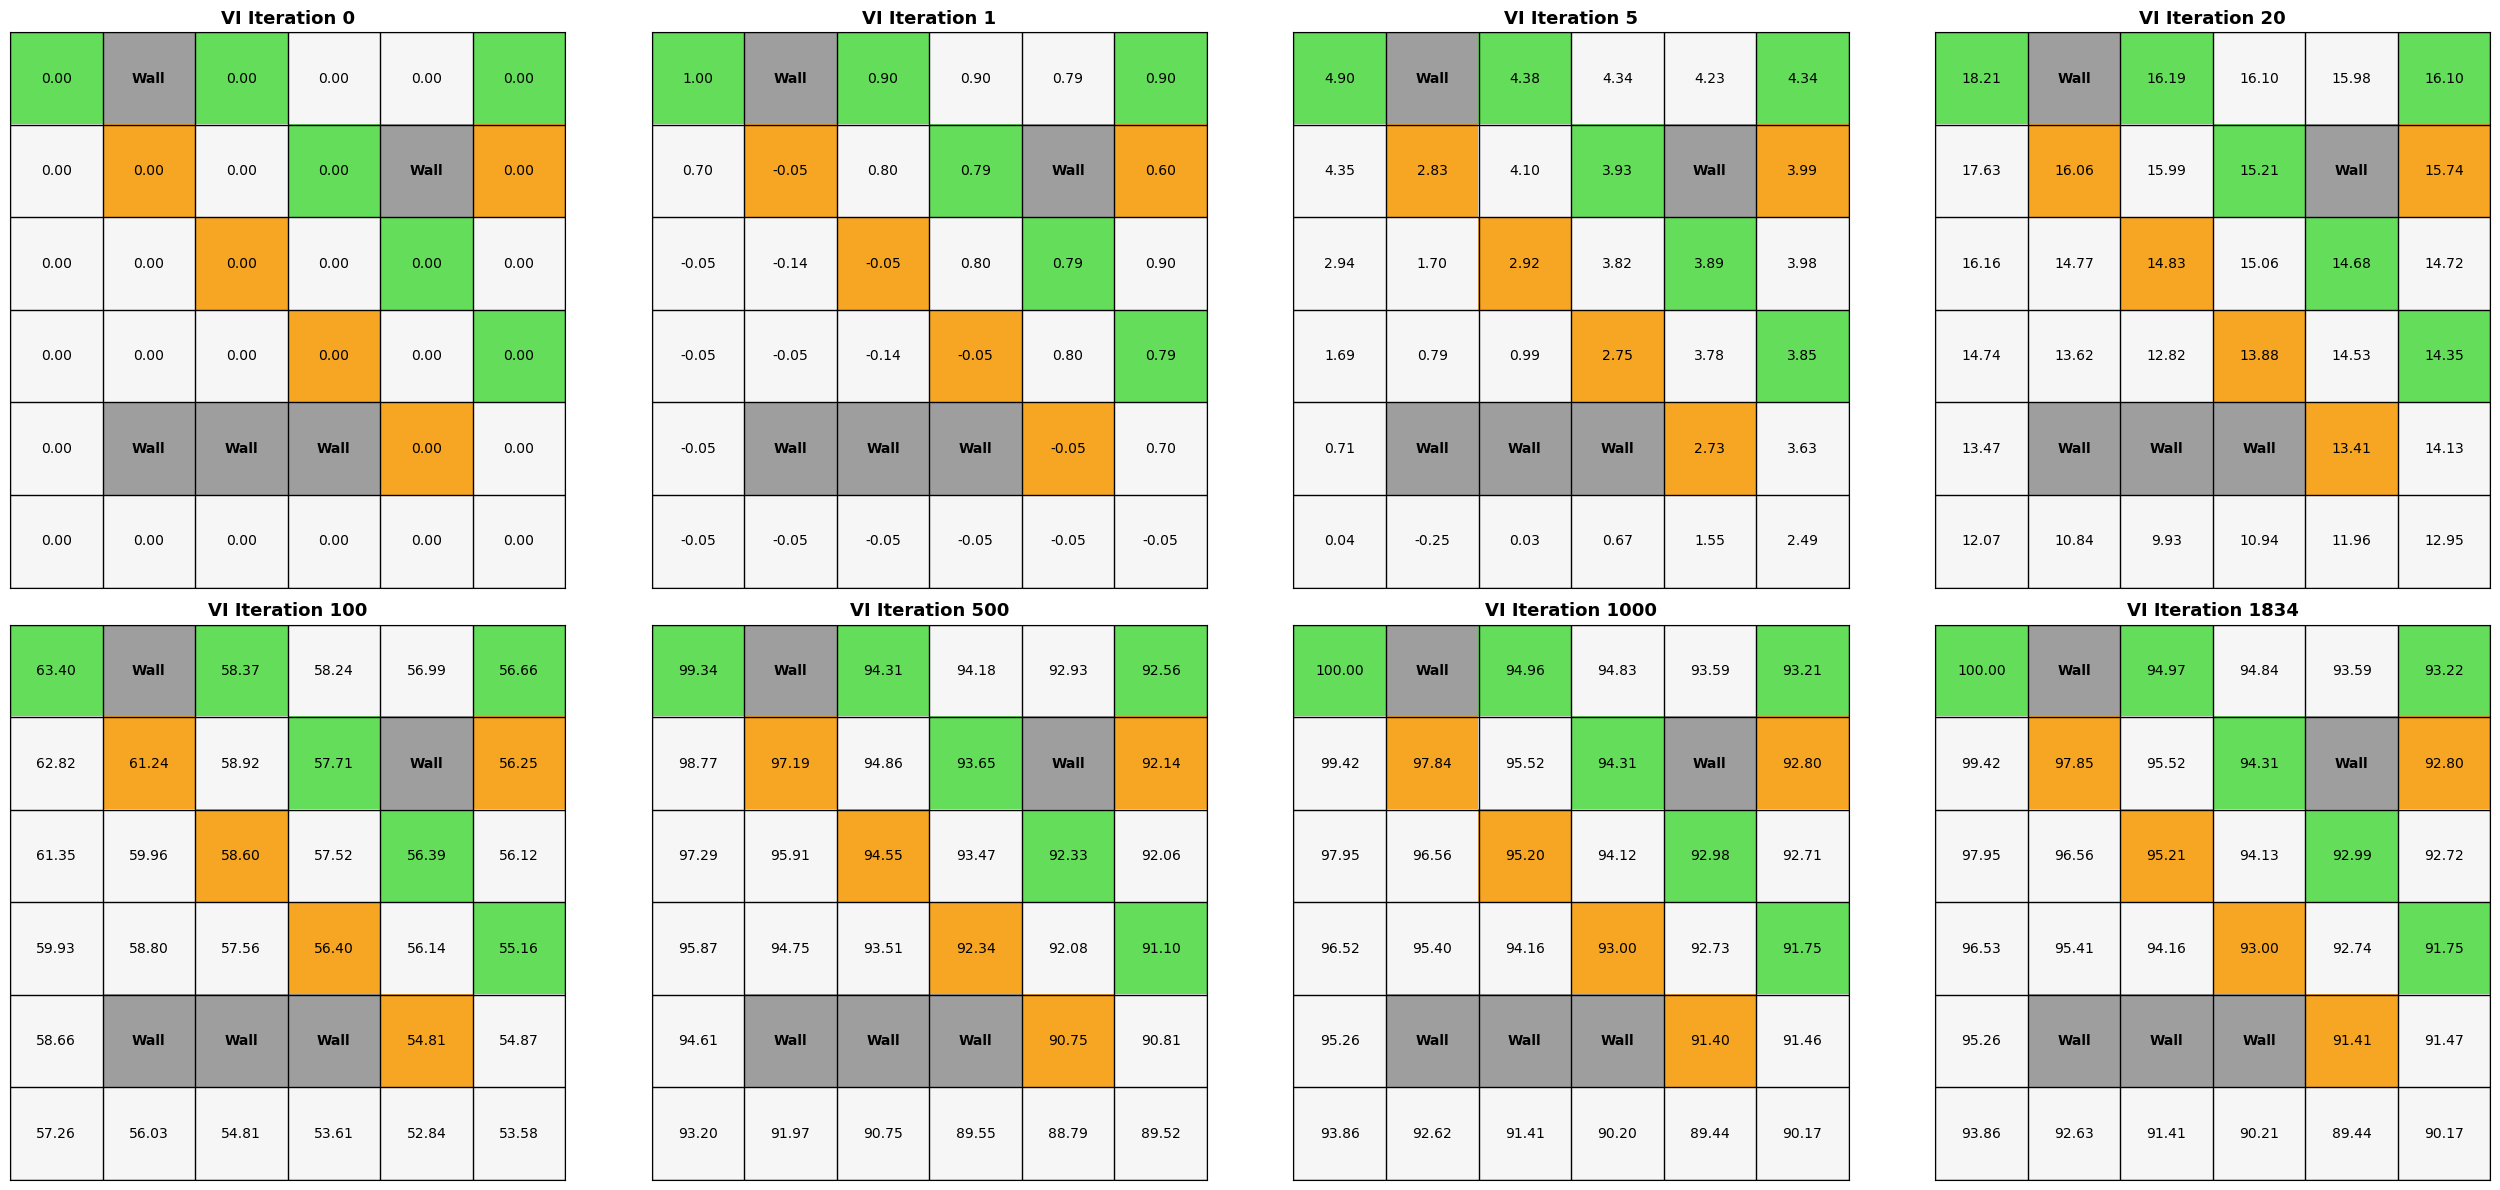

In [12]:
# Utility snapshots at different iterations
snapshot_iters = [0, 1, 5, 20, 100, 500, 1000, len(vi_history) - 1]
plot_snapshot_grid(
    env,
    vi_history,
    snapshot_indices=snapshot_iters,
    title_prefix='VI Iteration',
    ncols=4,
)

In [13]:
# Display optimal policy and utilities of all the states
display(utility_table_df(env, U_vi, decimals=3))
display(policy_table_df(env, policy_vi))

,c0,c1,c2,c3,c4,c5
r0,100.000,Wall,94.969,94.836,93.591,93.216
r1,99.425,97.846,95.522,94.310,Wall,92.802
r2,97.952,96.565,95.208,94.125,92.989,92.718
r3,96.529,95.406,94.165,93.001,92.738,91.753
r4,95.263,Wall,Wall,Wall,91.408,91.468
r5,93.861,92.628,91.411,90.209,89.443,90.175


,c0,c1,c2,c3,c4,c5
r0,↑,Wall,←,←,←,↑
r1,↑,←,←,←,Wall,↑
r2,↑,←,←,↑,←,←
r3,↑,←,←,↑,↑,↑
r4,↑,Wall,Wall,Wall,↑,↑
r5,↑,←,←,←,↑,↑


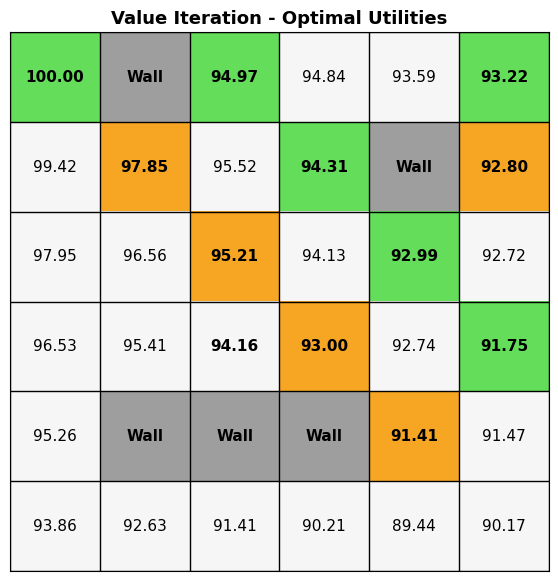

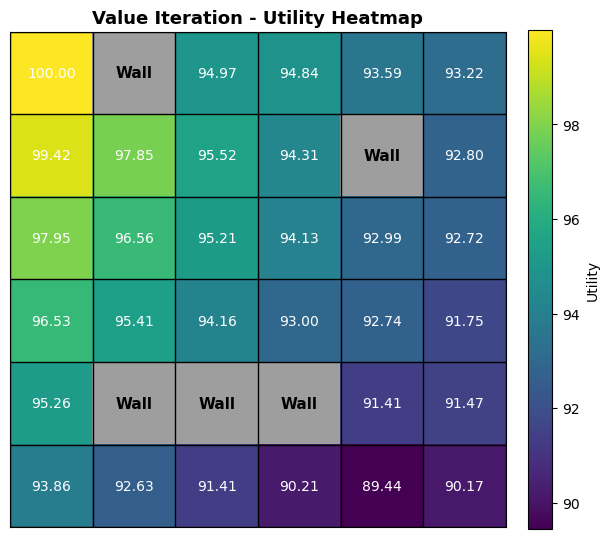

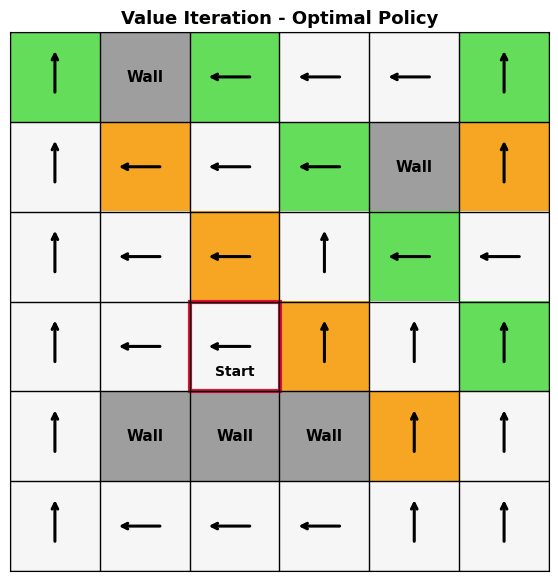

In [14]:
# Visualise optimal policy and utilities of all the states
plot_utilities_on_board(env, U_vi, title='Value Iteration - Optimal Utilities')
plot_utility_heatmap(env, U_vi, title='Value Iteration - Utility Heatmap')
plot_policy(env, policy_vi, title='Value Iteration - Optimal Policy')

## 5 Convergence Plots

The first graph plots utility estimates as a function of the number of iterations for several states, as in Figure 17.5(a).

The second graph shows the Bellman residual (maximum absolute utility change per sweep) on a log scale.


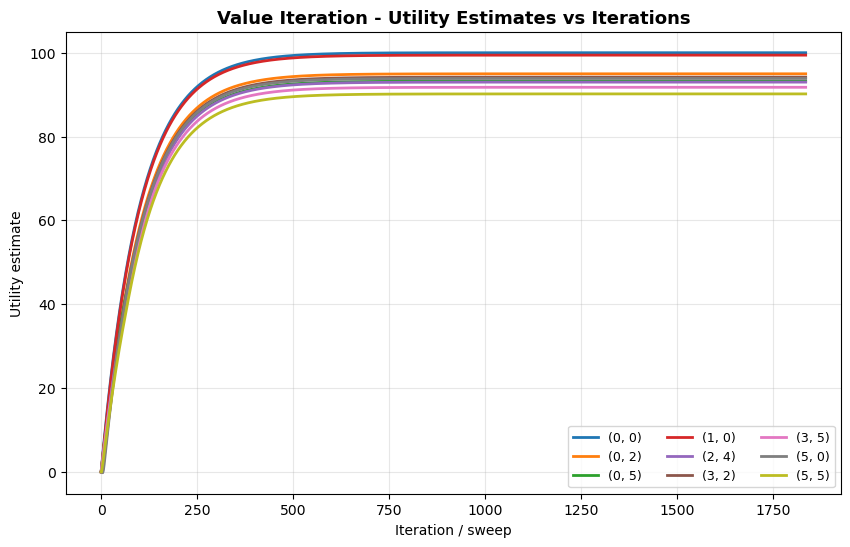

In [16]:
# Plot utility estimates as a function of the number of iterations
plot_state_traces(
    vi_history,
    TRACKED_STATES,
    title='Value Iteration - Utility Estimates vs Iterations'
)

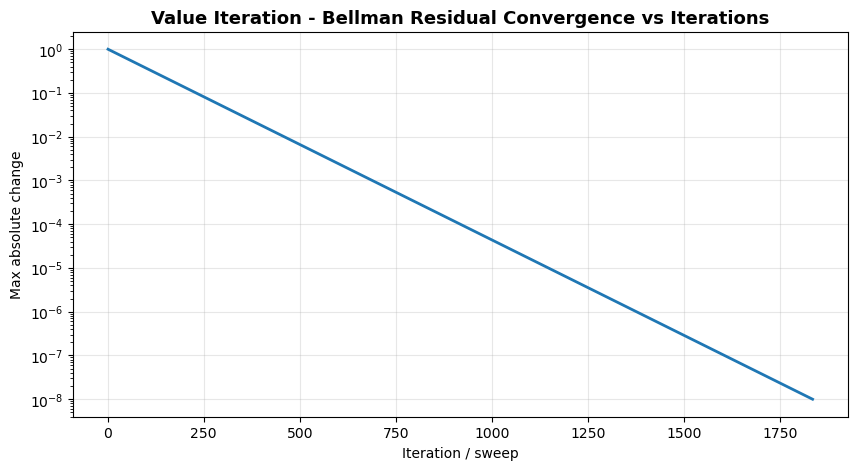

In [17]:
# Plot Bellman residual against iterations on a log scale
plot_delta_history(
    vi_deltas,
    title='Value Iteration - Bellman Residual Convergence vs Iterations',
    log_scale=True,
)